<a href="https://colab.research.google.com/github/rahiakela/deep-learning-research-and-practice/blob/main/neural-networks-from-scratch-in-python/03_activation_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

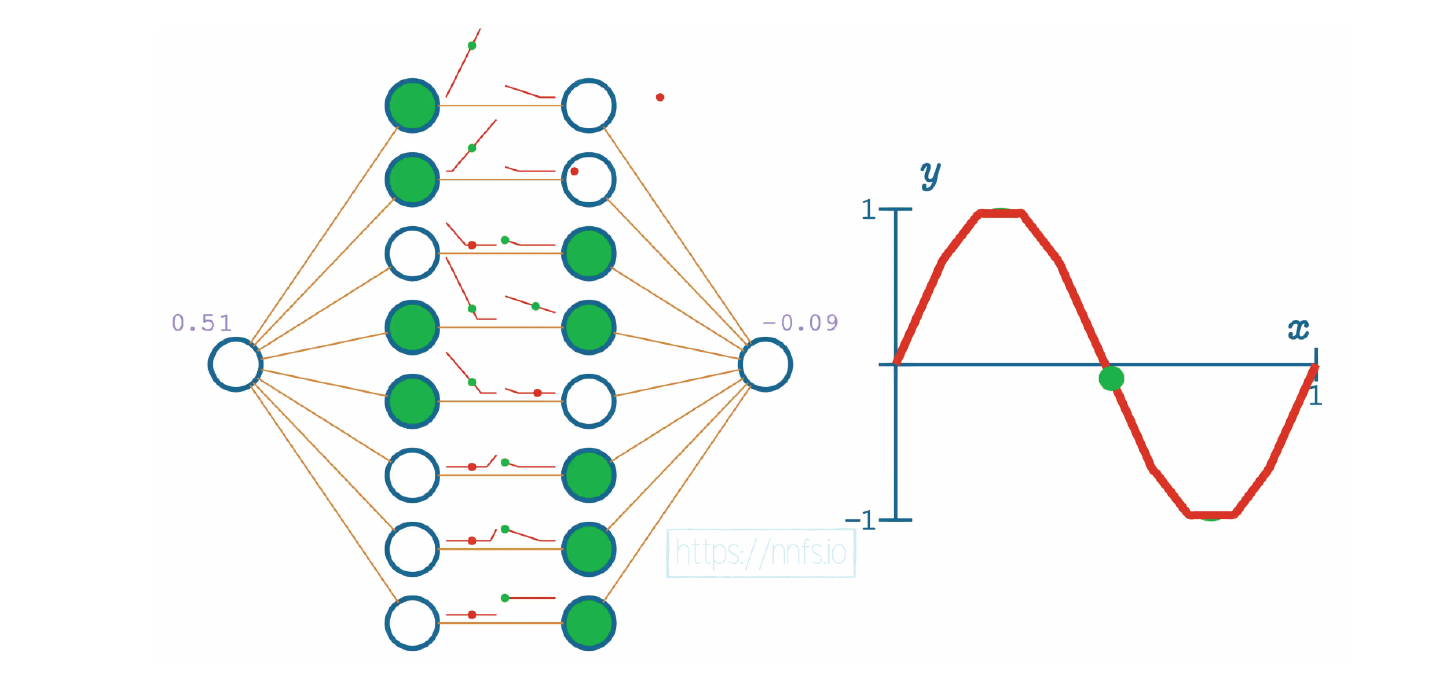

In [ ]:
!pip install nnfs

In [2]:
import numpy as np

import nnfs
from nnfs.datasets import spiral_data

import matplotlib.pyplot as plt

## Dense Layer

In [8]:
class DenseLayer:

  # Initialize weights and biases
  def __init__(self, n_inputs, n_neurons) -> None:
    # Note that we’re initializing weights to be (inputs, neurons), rather than ( neurons, inputs)
    self.weights = 0.01 * np.random.randn(n_inputs, n_neurons) # Gaussian distribution with a mean of 0 and a variance of 1
    self.bias = np.zeros((1, n_neurons))

  # Forward pass: Here, we pass data through a model from beginning to end
  def forward(self, inputs):
    # Calculate output values from inputs, weights and biases
    self.output = np.dot(inputs, self.weights) + self.bias

## ReLU Activation

The rectified linear activation function is straightforward where we’re checking if the current value is greater than 0. If it is, we’re appending it to the output list, and if it’s not, we’re appending 0.

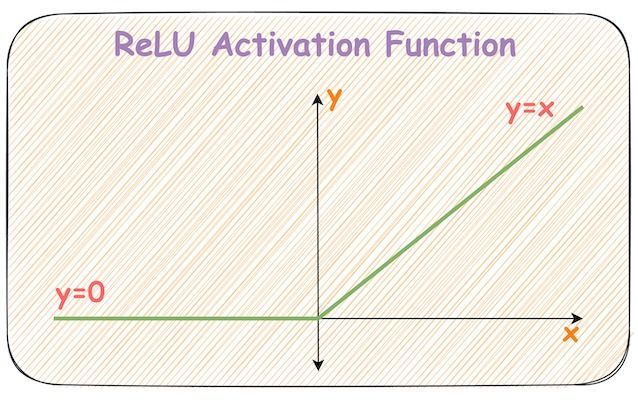

In [3]:
# simple ReLU example
inputs = [0 , 2 , - 1 , 3.3 , - 2.7 , 1.1 , 2.2 , - 100]

output = []
for i in inputs:
  if i > 0:
    output.append(i)
  else:
    output.append(0)

print(output)

[0, 2, 0, 3.3, 0, 1.1, 2.2, 0]


In [4]:
# max() function ReLU example
inputs = [0 , 2 , - 1 , 3.3 , - 2.7 , 1.1 , 2.2 , - 100]

output = []
for i in inputs:
  output.append(max(0, i))

print(output)

[0, 2, 0, 3.3, 0, 1.1, 2.2, 0]


In [5]:
# NumPy ReLU example
inputs = [0 , 2 , - 1 , 3.3 , - 2.7 , 1.1 , 2.2 , - 100]

output=np.maximum(0, inputs)

print(output)

[0.  2.  0.  3.3 0.  1.1 2.2 0. ]


In [6]:
class ReLU():
  def forward(self, inputs):
    # Calculate output values from input
    self.output = np.maximum(0, inputs)

Let’s apply this activation function to the dense layer’s outputs.

In [13]:
nnfs.init()

In [14]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 3 output values
dense_layer = DenseLayer(2, 3)

# Create ReLU activation (to be used with Dense layer)
relu_activation = ReLU()

# Perform a forward pass of our training data through this layer
dense_layer.forward(X)

# Forward pass through activation func
relu_activation.forward(dense_layer.output) # Takes in output from previous layer

# Let's see output of the first few samples:
print(relu_activation.output[:5])

[[0.         0.         0.        ]
 [0.         0.00011395 0.        ]
 [0.         0.00031729 0.        ]
 [0.         0.00052666 0.        ]
 [0.         0.00071401 0.        ]]


## Softmax Activation

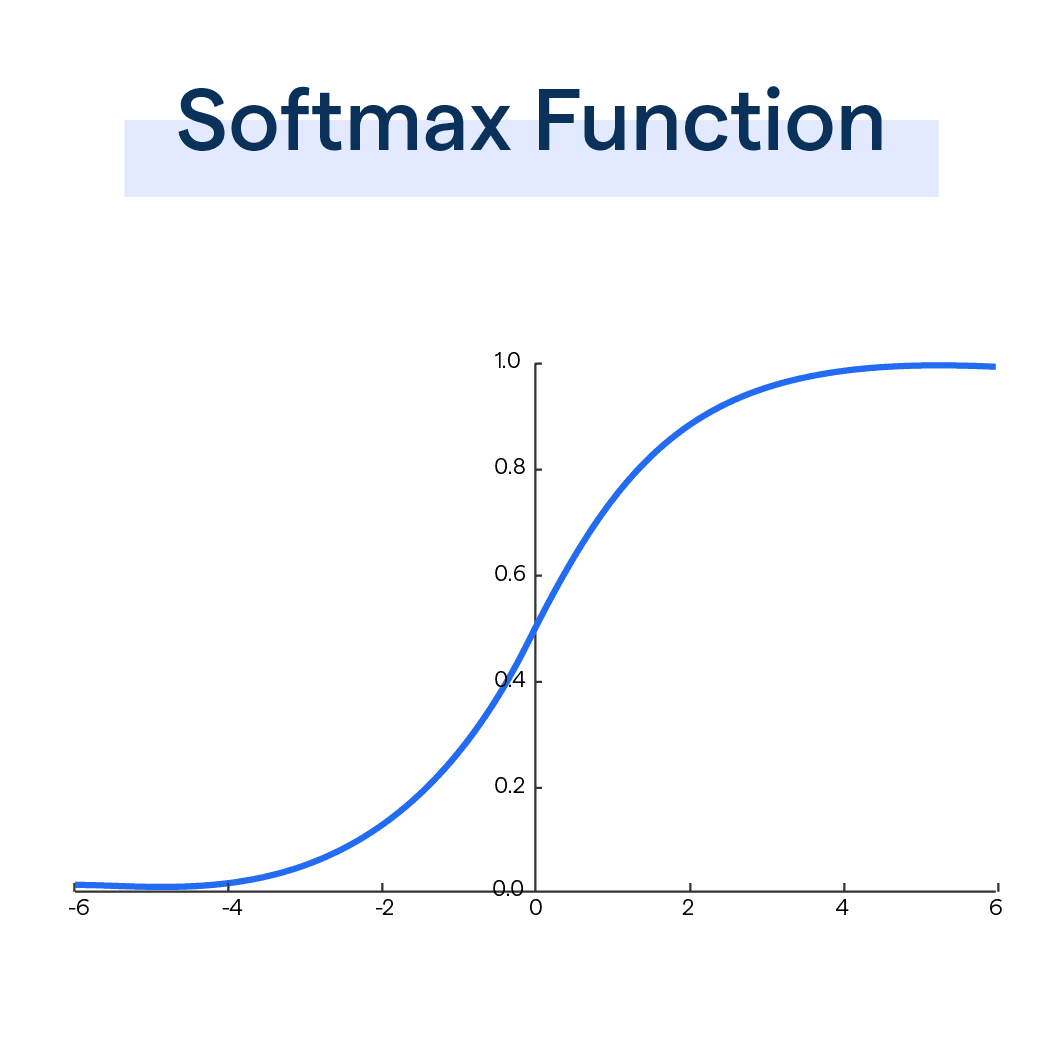

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.06467596e-04  6.03912667e-05 -1.60009622e-05]
 [ 1.75505862e-04  1.85229128e-05  3.20007302e-07]
 [ 6.23869637e-05 -2.52488389e-04  8.54709797e-05]
 [ 1.19885430e-04 -2.98626896e-04  1.02776539e-04]]
